In [153]:
# Force reinstall and upgrade lifelines to ensure a clean and up-to-date installation
!pip install --upgrade --force-reinstall lifelines

  Using cached lifelines-0.30.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached autograd_gamma-0.5.0-py3-none-any.whl
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached wrapt-2.2.1-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (

In [81]:
import random
import os
import numpy as np
import torch

def seed_everything(seed=42):

    random.seed(seed)                     # Python random
    np.random.seed(seed)                  # NumPy random

    torch.manual_seed(seed)               # PyTorch CPU
    torch.cuda.manual_seed_all(seed)      # PyTorch GPU

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(42)

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
# @title
import pandas as pd
df_all= pd.read_csv(r"/content/drive/MyDrive/Colab/Rail pc hazard/all_india_rail_final.csv",low_memory=False)
import scipy.integrate as integrate

if not hasattr(integrate, "simps") and hasattr(integrate, "simpson"):
    integrate.simps = integrate.simpson
df_all.shape

(2722669, 19)

In [84]:
df_ncr = df_all[df_all["RLYCODE"].astype(str).str.strip().str.upper() == "NCR"]

print(df_ncr.shape)


(127541, 19)


In [85]:
df_ncr = df_ncr[df_ncr["Weather_failed"].astype(str).str.strip().str.upper() == "0"]

print(df_ncr.shape)
df_ncr.sample(5)

(126969, 19)


,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
609261,NCR,AGRA,DHO - BHA,DN,60KG,65.160,130.0,215.0,RR,22.9,SWR,CURVE,1000,2021-09-01,GR,1498.0,0,2025-10-08,NaN
711129,NCR,PRYJ,PNK--ETW,UP,60KG,88.110,130.0,223.0,RR,22.32,LWR,STRAIGHT,1000,2021-12-01,GR,1407.0,0,2025-10-08,NaN
698244,NCR,PRYJ,KRJ-GZB,IIIRD LINE,60KG,28.200,130.0,72.0,RR,22.32,SWR,CURVE,800,2021-02-01,GR,1710.0,0,2025-10-08,NaN
691489,NCR,PRYJ,ETW-SKB,UP,60KG,65.440,130.0,353.0,RR,22.32,LWR,STRAIGHT,1000,2020-01-01,GR,2107.0,0,2025-10-08,NaN
717574,NCR,PRYJ,PRYJ-CNBI,UP,60KG,45.961,130.0,95.0,LR,22.32,LWR,STRAIGHT,1000,2023-06-01,GR,860.0,0,2025-10-08,NaN


In [86]:
df_ncr['SECTION'].value_counts()

,count
SECTION,
PRYJ-CNBI,9338
MTJ-OKA,8916
KRJ-GZB,7052
PNK--ETW,5701
CAR - COI,5483
...,...
PRG-PRYJ,55
BNPR - OHAN,46
HRS HRF,44


In [87]:
pd.set_option('display.max_columns', None)
df_ncr.isnull().sum().to_frame('Null Count').T

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
Null Count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,126969


In [88]:
cols_to_drop = ['RLYCODE']
df_ncr = df_ncr.drop(columns=cols_to_drop, errors='ignore')

In [89]:
df_ncr.DIVCODE.unique()

array(['AGRA', 'JHS', 'PRYJ'], dtype=object)

In [90]:
df_ncr.isnull().sum()

,0
DIVCODE,0
SECTION,0
LINE,0
RAIL_SECTION,0
ANNUAL_GMT,0
SPEED,0
GMTCARRIED,0
LRRR,0
AXLELOAD,0
TRACK_TYPE,0


In [91]:
df_ncr = df_ncr[df_ncr.DURATION>0]

In [92]:
p75 = df_ncr['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df_ncr['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5 *(p75-p25)
print("Upper limit:", p75 + iqr)


75th Percentile: 3477.0
25th Percentile: 891.0
Upper limit: 7356.0


In [93]:
df_ncr.DURATION.describe()

,DURATION
count,126969.000000
mean,2306.544976
std,1836.241294
min,7.000000
25%,891.000000
50%,1802.000000
75%,3477.000000
max,22895.000000


In [94]:

upper = p75 + iqr
df_ncr = df_ncr[df_ncr.DURATION <= upper]

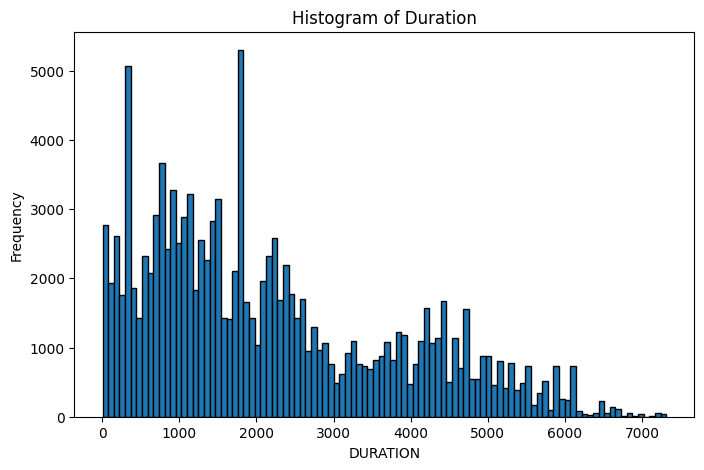

In [95]:
import matplotlib.pyplot as plt

# assuming df is your DataFrame
plt.figure(figsize=(8,5))
plt.hist(df_ncr["DURATION"], bins=100, edgecolor="black")
plt.xlabel("DURATION")
plt.ylabel("Frequency")
plt.title("Histogram of Duration")
plt.show()

Failure dataset

In [96]:
df_failure = df_all[df_all["RLYCODE"].astype(str).str.strip().str.upper() == "NCR"]

print(df_failure.shape)

(127541, 19)


In [97]:
df_failure = df_failure[df_failure["Weather_failed"].astype(str).str.strip().str.upper() == "1"]

print(df_failure.shape)
df_failure.sample(5)

(572, 19)


,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
2714316,NCR,AGRA,BTE-BKI,SL,52KG,28.034,110.0,383.84,RR,22.9,LWR,STRAIGHT,525,2015-01-09,GR,2918.0,1,NaN,2023-01-05
2717579,NCR,PRYJ,DDU-CAR,DN,60KG,35.133,130.0,786.00,RR,22.32,LWR,STRAIGHT,800,2011-01-03,GR,5096.0,1,NaN,2024-12-16
2713781,NCR,PRYJ,MKP LINK Jn,DN,60KG,33.480,110.0,365.43,LR,22.32,LWR,STRAIGHT,800,2016-01-07,GR,2132.0,1,NaN,2021-11-08
2716019,NCR,PRYJ,PNK--ETW,DN,60KG,76.940,130.0,685.15,RR,22.32,LWR,STRAIGHT,800,2011-01-05,GR,4335.0,1,NaN,2022-11-18
2717755,NCR,PRYJ,BRN ETH,SL,52KG,2.800,75.0,567.15,LR,22.32,LWR,STRAIGHT,350,2006-01-01,GR,5129.0,1,NaN,2020-01-17


In [98]:
len(df_failure.SECTION.unique())

57

In [99]:
df_failure[df_failure.DURATION ==0].describe()

,ANNUAL_GMT,SPEED,GMTCARRIED,SERVICE_LIFE,DURATION,Weather_failed
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


In [100]:
df_failure.DURATION.describe()

,DURATION
count,572.000000
mean,3030.858392
std,2111.822431
min,2.000000
25%,1104.750000
50%,3280.500000
75%,4369.750000
max,17919.000000


In [101]:
p75 = df_failure['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df_failure['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5*(p75-p25)
print("Upper limit:", p75 + iqr)

75th Percentile: 4369.75
25th Percentile: 1104.75
Upper limit: 9267.25


In [102]:
upper = p75 + iqr
df_failure[df_failure.DURATION ==0]

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1


In [103]:
df_failure = df_failure[df_failure.DURATION <= upper]

In [104]:
df_failure.DURATION.describe()

,DURATION
count,567.000000
mean,2948.619048
std,1911.637690
min,2.000000
25%,1099.500000
50%,3272.000000
75%,4353.500000
max,8431.000000


In [105]:
df_failure = df_failure.rename(columns={'FRACTURE_DATE.1': 'FRACTURE_DATE'})

In [106]:
df_failure.FRACTURE_DATE.max()

'2025-10-11'

In [107]:
df_failure.isnull().sum()

,0
RLYCODE,0
DIVCODE,0
SECTION,0
LINE,0
RAIL_SECTION,0
ANNUAL_GMT,21
SPEED,0
GMTCARRIED,5
LRRR,0
AXLELOAD,0


In [108]:
df_ncr.columns

Index(['DIVCODE', 'SECTION', 'LINE', 'RAIL_SECTION', 'ANNUAL_GMT', 'SPEED',
       'GMTCARRIED', 'LRRR', 'AXLELOAD', 'TRACK_TYPE', 'STRAIGHT_CURVE',
       'SERVICE_LIFE', 'LAYINGDATE.1', 'USFD_CLASSIFICATION', 'DURATION',
       'Weather_failed', 'Censoring_date', 'FRACTURE_DATE.1'],
      dtype='object')

In [109]:
df_failure.columns

Index(['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'RAIL_SECTION', 'ANNUAL_GMT',
       'SPEED', 'GMTCARRIED', 'LRRR', 'AXLELOAD', 'TRACK_TYPE',
       'STRAIGHT_CURVE', 'SERVICE_LIFE', 'LAYINGDATE.1', 'USFD_CLASSIFICATION',
       'DURATION', 'Weather_failed', 'Censoring_date', 'FRACTURE_DATE'],
      dtype='object')

In [110]:
df = df_all[df_all["RLYCODE"].astype(str).str.strip().str.upper() == "NCR"]

print(df.shape)
df.sample(5)

(127541, 19)


,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
710204,NCR,PRYJ,PNK--ETW,UP,60KG,65.440,130.0,368.0,LR,22.32,LWR,STRAIGHT,1000,2019-12-01,GR,2138.0,0,2025-10-08,NaN
705878,NCR,PRYJ,NYN-PRYJ,DN,60KG,35.805,130.0,263.0,RR,22.32,LWR,STRAIGHT,800,2023-05-01,GR,891.0,0,2025-10-08,NaN
651640,NCR,JHS,JHS GWL,DN,60KG,60.100,130.0,282.0,RR,22.32,LWR,STRAIGHT,1000,2020-09-01,GR,1863.0,0,2025-10-08,NaN
627169,NCR,AGRA,MTJ-OKA,IVTH LINE,60KG,77.760,160.0,86.0,RR,22.9,LWR,STRAIGHT,800,2019-01-01,GR,2472.0,0,2025-10-08,NaN
648323,NCR,JHS,JHS AIT,DN,60KG,19.680,110.0,125.0,RR,22.32,LWR,STRAIGHT,800,2010-07-01,GR,5578.0,0,2025-10-08,NaN


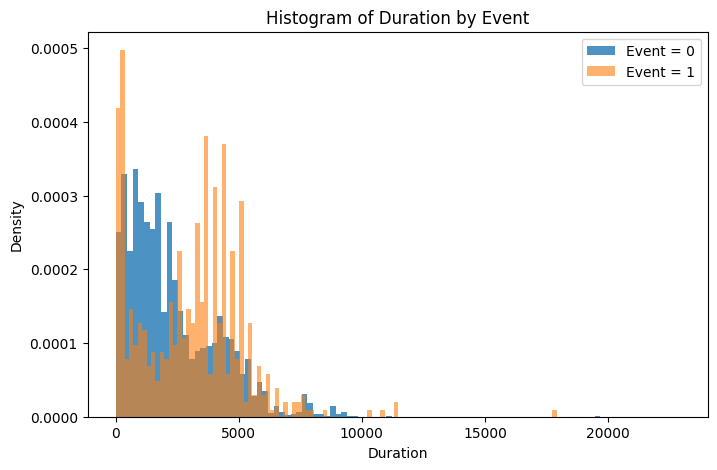

In [111]:
plt.figure(figsize=(8,5))

plt.hist(df[df["Weather_failed"] == 0]["DURATION"],
         bins=100, alpha=0.8, density=True, label="Event = 0")

plt.hist(df[df["Weather_failed"] == 1]["DURATION"],
         bins=100, alpha=0.6, density=True, label="Event = 1")

plt.xlabel("Duration")
plt.ylabel("Density")
plt.title("Histogram of Duration by Event")
plt.legend()
plt.show()



In [112]:
len(df)

127541

In [113]:
df[df.DIVCODE == "AGRA"].SECTION.unique()

array(['AF-AH', 'AGC-BKI CONNECTIVITY LINE', 'AGC-IDH', 'AGC-RKM',
       'AH-BTE', 'BHA-AGC', 'BHA-UDMR', 'BLNR - DHO', 'BTE-BKI',
       'BTE-MTJ', 'CIK-PRK CONNECTIVITY LINE', 'DHO - BHA',
       'ETUE (W)-MTI', 'ETUE-TDL', 'GWL - ETW', 'JAB -ETUE',
       'JAB(W LINE AF) -BXN', 'MTJ-AH', 'MTJ-AWR', 'MTJ-OKA', 'RKM-MTJ',
       'RKM-STRB', 'STRB-JAB', 'JAB(W line AF) -BXN',
       'AGC-BKI connectivity line'], dtype=object)

In [114]:
p75 = df['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5 *(p75-p25)
print("Upper limit:", p75 + iqr)


75th Percentile: 3477.0
25th Percentile: 891.0
Upper limit: 7356.0


In [115]:
upper = p75 + iqr
df = df[df.DURATION <= upper]

In [116]:
df['DURATION'].quantile(0.95)

np.float64(5274.0)

In [117]:
df.DURATION.describe()

,DURATION
count,124846.000000
mean,2180.527842
std,1615.572411
min,2.000000
25%,891.000000
50%,1802.000000
75%,3294.000000
max,7348.000000


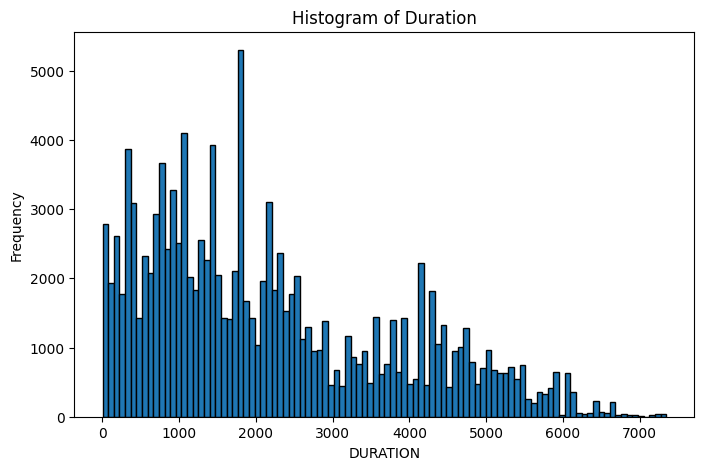

In [118]:
import matplotlib.pyplot as plt

# assuming df is your DataFrame
plt.figure(figsize=(8,5))
plt.hist(df["DURATION"], bins=100, edgecolor="black")
plt.xlabel("DURATION")
plt.ylabel("Frequency")
plt.title("Histogram of Duration")
plt.show()

In [119]:
df.Weather_failed.value_counts()

,count
Weather_failed,
0,124286
1,560


In [120]:
df['SECTION'].value_counts()

,count
SECTION,
PRYJ-CNBI,9381
MTJ-OKA,8940
KRJ-GZB,7061
PNK--ETW,5724
CAR - COI,5528
...,...
GWL SOE,12
JAB(W line AF) -BXN,12
AGD - MAKR CHORD LINE,10


In [121]:
df['LINE'].value_counts()

,count
LINE,
DN,41647
UP,40123
SL,30720
IIIRD LINE,9066
IVTH LINE,2374
OML,379
N,261
S,255
CHORD LINE,10


In [122]:
def reduce_line(line):
    if line in ["DN","DN 1", "DN 2"]:
        return "DN"
    elif line in ["SL", "IIIrd Line", "IVth Line", "MID"]:
        return "SL"
    elif line in ["UP 1", "UP 2","UP"]:
        return "UP"
    else:
        return "OT"

df["LINE"] = df["LINE"].apply(reduce_line)
df["LINE"].value_counts()


,count
LINE,
DN,41647
UP,40123
SL,30731
OT,12345


In [123]:
df =df[df['RAIL_SECTION']!= 'OTHER']

In [124]:
df.RAIL_SECTION.value_counts()

,count
RAIL_SECTION,
60KG,104306
52KG,20489


In [125]:
df['USFD_CLASSIFICATION'].value_counts()

,count
USFD_CLASSIFICATION,
GR,124773
OBS Joggled Plate,22


In [126]:

#Replace values to standardize categories
df['USFD_CLASSIFICATION'] = df['USFD_CLASSIFICATION'].replace({
    'DFWR(JP)': 'DFW',
    'DFWO(JP)': 'DFW',
    'DFWO': 'DFW',
    'DFW(JP)': 'DFW',
    'DFWR': 'DFW',
    'DFWO Joggled Plate': 'DFW',
    'DFWR Joggled Plate': 'DFW',
    'OBS(W)(JP)': 'OBS',
    'OBS(W) Joggled Plate': 'OBS',
    'OBS(W)': 'OBS',
    'DFWN' : 'DFW',
'DFW Joggled Plate' : 'DFW'


})


In [127]:
df['USFD_CLASSIFICATION'].value_counts()

,count
USFD_CLASSIFICATION,
GR,124773
OBS Joggled Plate,22


In [128]:
df['USFD_CLASSIFICATION'].unique()

array(['GR', 'OBS Joggled Plate'], dtype=object)

In [129]:
import numpy as np
import re

def clean_axle_load(x):
    if pd.isna(x):
        return np.nan

    # Convert to string
    x = str(x).strip()

    # Handle ranges like "Up to 20.32"
    if "up to" in x.lower():
        num = re.findall(r"\d+\.?\d*", x)
        return int(round(float(num[0]))) if num else np.nan

    # Extract numeric part
    num = re.findall(r"\d+\.?\d*", x)
    if num:
        return int(round(float(num[0])))

    return np.nan


df["AXLELOAD"] = df["AXLELOAD"].apply(clean_axle_load)

df['AXLELOAD'].value_counts()

,count
AXLELOAD,
22,83865
23,40930


In [130]:

df['RAIL_SECTION'] = df['RAIL_SECTION'].str.replace('KG', '', regex=False).astype(int)

In [131]:
df['RAIL_SECTION'].value_counts()

,count
RAIL_SECTION,
60,104306
52,20489


Encoding

In [132]:
import torch
import torch.nn as nn
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Identify all object dtype columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)


Categorical columns: ['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'LRRR', 'TRACK_TYPE', 'STRAIGHT_CURVE', 'LAYINGDATE.1', 'USFD_CLASSIFICATION', 'Censoring_date', 'FRACTURE_DATE.1']


In [133]:
p95 = df['DURATION'].quantile(0.99)
print("95th Percentile:", p95)

95th Percentile: 6124.0


In [134]:
pd.set_option('display.max_columns', None)
df.isnull().sum().to_frame('Null Count').T

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
Null Count,0,0,0,0,0,21,0,5,0,0,0,0,0,0,0,0,0,559,124236


***Modeling***

In [135]:
!pip install torchtuples
import torch # For building the networks
import torchtuples as tt # Some useful functions

In [136]:


# Step 2: Convert dates to datetime
df['FRACTURE_DATE.1'] = pd.to_datetime(df['FRACTURE_DATE.1'], errors='coerce')
df['LAYINGDATE.1'] = pd.to_datetime(df['LAYINGDATE.1'], errors='coerce')

# Step 3: Split failed and censored
df_failed = df[df['Weather_failed'] == 1]
df_censored = df[df['Weather_failed'] == 0]

# Step 4: Take latest FAILURE per ID
df_failed_last = df_failed.sort_values('FRACTURE_DATE.1')

# Step 5: Take latest CENSORING per ID
df_censored_last = df_censored.sort_values('LAYINGDATE.1')

# Step 6: Combine
df= pd.concat([df_failed_last, df_censored_last])

# Step 7: Safety check

print("Total rows:", len(df))

Total rows: 124795


In [137]:
df.shape

(124795, 19)

In [138]:
df

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,LAYINGDATE.1,USFD_CLASSIFICATION,DURATION,Weather_failed,Censoring_date,FRACTURE_DATE.1
2712926,NCR,AGRA,AGC-RKM,DN,60,61.210,160.0,188.27,LR,23,LWR,STRAIGHT,800,2012-01-07,GR,1105.0,1,NaN,2015-01-16
2713657,NCR,AGRA,MTJ-AWR,SL,60,23.230,110.0,65.67,LR,23,LWR,STRAIGHT,800,2010-01-04,GR,1880.0,1,NaN,2015-02-27
2714140,NCR,AGRA,MTJ-AWR,SL,60,23.230,110.0,71.04,LR,23,LWR,CURVE,800,2009-01-02,GR,2498.0,1,NaN,2015-11-05
2710662,NCR,JHS,JHS GWL,UP,60,61.780,130.0,102.74,LR,22,LWR,CURVE,800,2014-03-19,GR,610.0,1,NaN,2015-11-19
2716172,NCR,JHS,JHS GWL,DN,60,72.960,130.0,862.49,LR,22,SWR,STRAIGHT,800,2004-01-03,GR,4359.0,1,NaN,2015-12-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709048,NCR,PRYJ,PNK--ETW,DN,60,43.945,130.0,4.00,RR,22,LWR,STRAIGHT,800,2025-10-01,GR,7.0,0,2025-10-08,NaT
709047,NCR,PRYJ,PNK--ETW,DN,60,43.945,130.0,4.00,RR,22,LWR,STRAIGHT,800,2025-10-01,GR,7.0,0,2025-10-08,NaT
709046,NCR,PRYJ,PNK--ETW,DN,60,43.945,130.0,4.00,RR,22,LWR,CURVE,800,2025-10-01,GR,7.0,0,2025-10-08,NaT
709049,NCR,PRYJ,PNK--ETW,DN,60,43.945,130.0,4.00,RR,22,LWR,STRAIGHT,800,2025-10-01,GR,7.0,0,2025-10-08,NaT


In [139]:
df['NEW_GMT'] = (df['DURATION']/365)*df['ANNUAL_GMT']
rail_map = { 52: 1,60: 2}
df["RAIL_SECTION"] = df["RAIL_SECTION"].map(rail_map)

# df["GMT_NO"] = df["GMT_CARRIED"] /df["ANNUAL_GMT"]
df["ANNUAL_LOAD"] = df["ANNUAL_GMT"] * df["AXLELOAD"]
df["AXLELOAD"]  = df["AXLELOAD"].map({22: 1, 23:2})
df["SPEED_AGMT"] = df["SPEED"] * df["ANNUAL_GMT"]


In [140]:
df = df.drop(columns=['LAYINGDATE.1', 'Censoring_date', 'FRACTURE_DATE.1', 'ANNUAL_GMT'])
df.sample(5)

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,USFD_CLASSIFICATION,DURATION,Weather_failed,NEW_GMT,ANNUAL_LOAD,SPEED_AGMT
687476,NCR,PRYJ,DDU-CAR,DN,2,130.0,300.0,LR,1,LWR,CURVE,1000,GR,2199.0,0,313.523178,1144.88,6765.2
664964,NCR,JHS,LAR JHS,OT,2,130.0,68.0,LR,1,LWR,CURVE,800,GR,1376.0,0,67.857534,396.00,2340.0
640290,NCR,JHS,AIT BZM,UP,2,110.0,80.0,RR,1,SWR,STRAIGHT,800,GR,1195.0,0,97.236986,653.40,3267.0
704064,NCR,PRYJ,MKP LINK JN,UP,2,110.0,124.0,RR,1,LWR,STRAIGHT,800,GR,1376.0,0,143.556384,837.76,4188.8
716467,NCR,PRYJ,PRYJ-CNBI,DN,2,130.0,304.0,RR,1,LWR,CURVE,1000,GR,2503.0,0,359.951973,1154.78,6823.7


In [141]:
df= df[df.DURATION >0]

In [142]:
df.dropna(inplace= True)

In [143]:
df.shape

(124774, 18)

In [144]:
# If not installed
!pip install lifelines

from lifelines import CoxPHFitter
from sklearn.model_selection import train_test_split

In [145]:
!pip install scikit-survival

In [148]:
from lifelines import CoxPHFitter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

# Define duration and event columns
duration_col = 'DURATION'
event_col = 'Weather_failed'

# Identify features (excluding duration and event columns)
# RLYCODE is dropped because it's constant after filtering to 'NCR'
# 'SECTION' and 'LINE' are dropped due to low variance/complete separation issues in some categories after one-hot encoding
features = [col for col in df.columns if col not in [duration_col, event_col, 'RLYCODE', 'SECTION', 'LINE']]

# Identify categorical and numerical features based on current dtypes in df
categorical_features = df[features].select_dtypes(include='object').columns.tolist()
numerical_features = df[features].select_dtypes(include=np.number).columns.tolist()

# Create a preprocessor for one-hot encoding categorical features
# Added sparse_output=False to OneHotEncoder for more predictable dense array output
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Apply preprocessing to the features
X_processed = preprocessor.fit_transform(df[features])

# Get feature names after one-hot encoding
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
processed_feature_names = list(ohe_feature_names) + numerical_features

# Convert X_processed to DataFrame for CoxPHFitter
cox_data_features = pd.DataFrame(X_processed, columns=processed_feature_names, index=df.index)

# Combine processed features with duration and event for lifelines
cox_data = cox_data_features.copy()
cox_data[duration_col] = df[duration_col]
cox_data[event_col] = df[event_col]

# Split the data into training and testing sets
train_data, test_data = train_test_split(cox_data, test_size=0.2, random_state=42)

# Instantiate and fit the Penalised Cox (L2) model
# l1_ratio=0 for Ridge (L2) penalty, penalizer determines the strength of the penalty
cph = CoxPHFitter(l1_ratio=0, penalizer=0.1) # penalizer value can be tuned
cph.fit(train_data, duration_col=duration_col, event_col=event_col)

# Evaluate the model
# C-index
c_index_train = cph.score(train_data, scoring_method="concordance_index")
c_index_test = cph.score(test_data, scoring_method="concordance_index")

print(f"C-index (train): {c_index_train:.4f}")
print(f"C-index (test): {c_index_test:.4f}")

# Note on RMSE: RMSE is typically used for regression tasks, not survival analysis.
# Metrics like C-index are more appropriate for evaluating survival models
# as they account for censoring and the probabilistic nature of survival predictions.


C-index (train): 0.7398
C-index (test): 0.6925


In [150]:
import numpy as np

# Predict expected survival time for the test set
# cph.predict_expectation() estimates the expected event time for each individual.
predicted_expected_durations = cph.predict_expectation(test_data[processed_feature_names])

# Get actual durations from the test set
actual_durations = test_data[duration_col]

# Calculate RMSE
# While RMSE is not standard for survival analysis, if we treat the expected survival time as a prediction
# for the actual duration, we can compute RMSE.
# However, this metric should be interpreted with extreme caution due to censoring, as for censored observations,
# the 'actual duration' is a lower bound, not the true event time.
rmse = np.sqrt(np.mean((predicted_expected_durations - actual_durations)**2))

print(f"RMSE (predicted expected duration vs. actual duration): {rmse:.4f}")
print("\nNOTE: RMSE is generally not a standard or appropriate metric for evaluating survival models directly.")
print("Survival models deal with time-to-event data, which often includes censoring (where the event has not yet occurred or was unobserved).")
print("For censored observations, the 'actual duration' is only a minimum observation time, not the true event time, making a direct RMSE calculation misleading.")
print("Metrics like C-index are more appropriate as they specifically account for censoring and the probabilistic nature of survival predictions.")


RMSE (predicted expected duration vs. actual duration): 5292.4062

NOTE: RMSE is generally not a standard or appropriate metric for evaluating survival models directly.
Survival models deal with time-to-event data, which often includes censoring (where the event has not yet occurred or was unobserved).
For censored observations, the 'actual duration' is only a minimum observation time, not the true event time, making a direct RMSE calculation misleading.
Metrics like C-index are more appropriate as they specifically account for censoring and the probabilistic nature of survival predictions.


In [158]:
from lifelines.utils import integrated_brier_score
import numpy as np

# Use the same time_points as before
time_points = np.linspace(test_data[duration_col].min(), test_data[duration_col].max(), 100).round()
time_points = time_points[time_points > 0] # Ensure time points are positive

# Calculate IBS using the integrated_brier_score function directly
# It requires the fitted model, training data, and testing data
ibs = integrated_brier_score(cph, train_data, test_data, duration_col, event_col, time_points=time_points)
print(f"Integrated Brier Score (IBS): {ibs:.4f}")

ImportError: cannot import name 'integrated_brier_score' from 'lifelines.utils' (/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py)